# Подготовка данных

1. Загрузка датасета
2. Очистка и нормализация текста (плейсхолдеры не трогаем)
3. Стратифицированный сплит train/test (80/20)
4. Анализ классов, требующих аугментации

In [ ]:
import json
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

DATA_PATH = Path('/content/original_data.json')
OUTPUT_DIR = Path('/content/ann_data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Загрузка датасета

In [ ]:
with open(DATA_PATH, encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)[['label', 'text']]
print(f'Документов: {len(df)}')
print(f'Классов: {df["label"].nunique()}')
df.head(3)

Документов: 1774
Классов: 36


,label,text
0,Блок директора по проектированию,[PERSON]\n\nУважаемый [PERSON]!\n\n[ORGANIZATI...
1,Блок деректора по газу,[ORGANIZATION] инжиниринг общество с ограничен...
2,Блок заместителя генерального директора по без...,[ORGANIZATION] ИНВЕСТ Общество с ограниченной ...


## 2. Очистка текста

Многоступенчатая очистка деловых писем. Для контекстуальных моделей важно убрать технические артефакты, не искажая смысл:
- нормализация кавычек, тире и пробелов;
- удаление подряд идущих повторяющихся слов;
- удаление длинных повторяющихся фрагментов (зацикливания);
- удаление дублирующихся строк и предложений;
- обрезка прикреплённых документов (договоры, акты, положения, таблицы);
- удаление аномальных писем (много слов при малом числе уникальных).

**Плейсхолдеры `[PERSON]`, `[ORGANIZATION]` и т.д. не трогаются.**

In [ ]:
def remove_repeated_words(text: str) -> str:
    """Убирает подряд идущие одинаковые слова: 'оплата оплата' -> 'оплата'."""
    return re.sub(r'\b(\w+)(\s+\1\b)+', r'\1', text, flags=re.IGNORECASE)


def remove_repeated_chunks(text: str, min_w: int = 5, max_w: int = 30) -> str:
    """Убирает длинные повторяющиеся последовательности слов (зацикливание)."""
    words = text.split()
    out, i = [], 0
    while i < len(words):
        matched = False
        for size in range(max_w, min_w - 1, -1):
            if i + 2 * size > len(words):
                continue
            if words[i:i + size] == words[i + size:i + 2 * size]:
                out.extend(words[i:i + size])
                j = i + size
                while j + size <= len(words) and words[j:j + size] == words[i:i + size]:
                    j += size
                i, matched = j, True
                break
        if not matched:
            out.append(words[i]); i += 1
    return ' '.join(out)


def remove_duplicate_lines(text: str) -> str:
    """Убирает повторяющиеся строки, сохраняя порядок."""
    seen, out = set(), []
    for line in text.split('\n'):
        norm = line.strip().lower()
        if not norm:
            out.append(line)
        elif norm not in seen:
            out.append(line); seen.add(norm)
    return '\n'.join(out)


def remove_duplicate_sentences(text: str) -> str:
    """Убирает повторяющиеся предложения."""
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    seen, out = set(), []
    for s in sents:
        key = s.strip().lower()
        if key and key not in seen:
            seen.add(key); out.append(s.strip())
    return ' '.join(out)


def trim_attachments(text: str, max_len: int = 4000) -> str:
    """Обрезает прикреплённые документы (договоры, акты, положения, оферты)."""
    if len(text) <= max_len:
        return text
    triggers = [
        r'[Тт]аблиц[а-я]*',
        r'Публичная оферта',
        r'заключили настоящий [Дд]оговор',
        r'1\.\s*Предмет договора',
        r'Термины и определения',
        r'Акт сверки',
        r'Акт\s+№?\s*\d+',
        r'Приложение\s+\d+\s+к',
        r'ПОЛОЖЕНИЕ\s+О\s+',
        r'1\.\s*Общие положения',
    ]
    cut = len(text)
    for trig in triggers:
        m = re.search(trig, text)
        if m:
            cut = min(cut, m.start())
    return text[:cut].strip() if cut < len(text) else text


def clean_text(text: str) -> str:
    """Полная очистка: прогон через все фильтры по порядку."""
    if not isinstance(text, str):
        return text
    # нормализация кавычек и тире
    text = text.replace('\u00ab', '"').replace('\u00bb', '"')
    text = text.replace('\u2013', '-').replace('\u2014', '-')
    # чистка повторов
    text = remove_repeated_words(text)
    text = remove_repeated_chunks(text)
    text = remove_duplicate_lines(text)
    text = remove_duplicate_sentences(text)
    # обрезка приложений
    text = trim_attachments(text)
    # нормализация пробелов
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n\s*\n+', '\n\n', text)
    return text.strip()


def is_anomalous(text: str) -> bool:
    """Аномальное письмо: много слов, но почти все повторяются."""
    words = re.findall(r'\b\w+\b', text.lower())
    return len(words) > 200 and len(set(words)) < 50


# --- применяем очистку ---
chars_before = df['text'].str.len().sum()
n_before = len(df)

# удаляем аномальные письма (проверка на сыром тексте)
df = df[~df['text'].apply(is_anomalous)].reset_index(drop=True)
n_anomalous = n_before - len(df)

# чистим тексты
df['text'] = df['text'].apply(clean_text)

# убираем опустевшие после очистки
df = df[df['text'].str.strip().astype(bool)].reset_index(drop=True)

chars_after = df['text'].str.len().sum()
reduction = (1 - chars_after / chars_before) * 100
print(f'Удалено аномальных писем: {n_anomalous}')
print(f'Документов после очистки: {len(df)}')
print(f'Сокращение объёма текста: {reduction:.1f}%')

Удалено аномальных писем: 19
Документов после очистки: 1755
Сокращение объёма текста: 45.3%


In [ ]:
# Сохраняем очищенный датасет
df.to_csv(OUTPUT_DIR / 'cleaned_df.csv', index=False)
print('Сохранено:', OUTPUT_DIR / 'cleaned_df.csv')

Сохранено: /content/ann_data/cleaned_df.csv


## 3. Стратифицированный сплит train / test

In [ ]:
# гарантируется хотя бы 1 пример каждого класса в тесте:
# сначала берём по 1 документу из каждого класса в тест,
# остаток делим стратифицированно 80/20

RANDOM_STATE = 42
TEST_SIZE = 0.2

# по 1 документу из каждого класса -> в тест
test_min = df.groupby('label', group_keys=False).sample(n=1, random_state=RANDOM_STATE)
remaining = df.drop(index=test_min.index)

# сколько ещё нужно в тест
target_test_n = int(round(len(df) * TEST_SIZE)) - len(test_min)

# из остатка берём классы с >= 2 примерами (для stratify)
vc = remaining['label'].value_counts()
ok_labels = vc[vc >= 2].index
remaining_ok = remaining[remaining['label'].isin(ok_labels)]
remaining_bad = remaining[~remaining['label'].isin(ok_labels)]

train_extra, test_extra = train_test_split(
    remaining_ok,
    test_size=target_test_n,
    random_state=RANDOM_STATE,
    stratify=remaining_ok['label'],
)

train_df = pd.concat([train_extra, remaining_bad], ignore_index=True)
test_df = pd.concat([test_extra, test_min], ignore_index=True)

train_df.to_csv(OUTPUT_DIR / 'train.csv', index=False)
test_df.to_csv(OUTPUT_DIR / 'test.csv', index=False)

print(f'Трейн: {train_df.shape}')
print(f'Тест:  {test_df.shape}')

Трейн: (1404, 2)
Тест:  (351, 2)


In [ ]:
# Проверяем, что все классы есть в обоих сплитах
train_labels = set(train_df['label'])
test_labels = set(test_df['label'])
print(f'Классов в трейне: {len(train_labels)}')
print(f'Классов в тесте:  {len(test_labels)}')
print(f'Классов только в трейне: {len(train_labels - test_labels)}')
print(f'Классов только в тесте: {len(test_labels - train_labels)}')

Классов в трейне: 36
Классов в тесте:  36
Классов только в трейне: 0
Классов только в тесте: 0


## 4. Анализ: какие классы нуждаются в аугментации

In [ ]:
AUGMENTATION_THRESHOLD = 30  # целевой минимум на класс в трейне

train_counts = train_df['label'].value_counts().sort_values()
need_aug = train_counts[train_counts < AUGMENTATION_THRESHOLD]
ok = train_counts[train_counts >= AUGMENTATION_THRESHOLD]

print(f'Классов >= {AUGMENTATION_THRESHOLD} документов: {len(ok)}')
print(f'Классов < {AUGMENTATION_THRESHOLD} документов (нужна аугментация): {len(need_aug)}')
print()

aug_plan = pd.DataFrame({
    'label': need_aug.index,
    'count_train': need_aug.values,
    'need_to_generate': AUGMENTATION_THRESHOLD - need_aug.values
})
aug_plan = aug_plan.sort_values('count_train')
aug_plan

Классов >= 30 документов: 13
Классов < 30 документов (нужна аугментация): 23



,label,count_train,need_to_generate
0,Проект «Трубопроводный транспорт Ещё одного НГКМ»,1,29
1,Блок заместителя генерального директора по стр...,1,29
2,Имущественные вопросы,1,29
3,Подразделение по информационным технологиям,1,29
4,Проект «Обустройство объектов Новейшей нейти»,2,28
5,Блок исполнительного директора по реализации п...,3,27
6,"Проект ""Обустройство площадных объектов НГКМ П...",4,26
7,Проект «Обустройство Интересного лицензионного...,5,25
8,Управление коммуникаций,5,25
9,Блок бизнес-директора,6,24


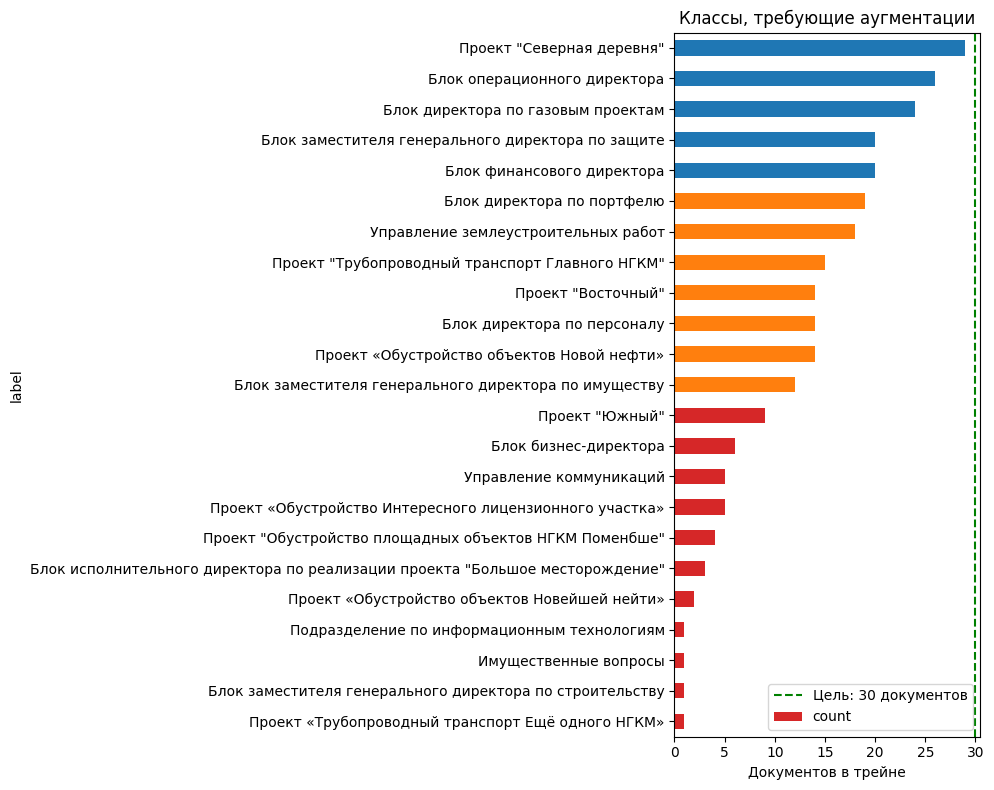

In [ ]:
# Сохраняем план аугментации
aug_plan.to_csv(OUTPUT_DIR / 'augmentation_plan.csv', index=False)

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#d62728' if c < 10 else '#ff7f0e' if c < 20 else '#1f77b4'
          for c in need_aug.values]
need_aug.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=AUGMENTATION_THRESHOLD, color='green', linestyle='--',
           label=f'Цель: {AUGMENTATION_THRESHOLD} документов')
ax.set_xlabel('Документов в трейне')
ax.set_title('Классы, требующие аугментации')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'augmentation_targets.png', dpi=150)
plt.show()